# 解答例：模様特徴量の課題

元Notebook：[22_snake_pattern_features.ipynb](../22_snake_pattern_features.ipynb)．

課題と解答例，実行に必要な定義だけをまとめている．上から実行すると，手計算できる例と既知の波長を使って結果を確認できる．

## 課題：実装と検証

1. `make_equal_area_patterns()` を作り，前景画素数が厳密に等しく，連結成分数が異なる2画像を生成する．たとえば64×64画像上の16×16正方形1個と，離れた8×8正方形4個を使い，表と `assert` で確認する．
2. `make_diagonal_touch_example()` を作り，4近傍と8近傍の成分数を比較する．端をまたぐ例も加え，開いた境界と周期境界の違いを検証する．
3. `noise_sensitivity(image, noise_levels, seed)` を作り，面積比，連結成分数，特徴波長をDataFrameにする．同じ基礎乱数を強度倍し，値域を自動的に0から1へ切り詰めない．その後，別seed，閾値，平滑化の影響を比較する．
4. `wavelength_checks()` を作り，一定画像，波長16と32，画像幅が1周期の画像，長方形画像を検証する．画素間隔が違う場合の実長への換算も `assert` で確かめる．
5. 面積比，成分数，波長がそれぞれ区別できない模様と，処理に敏感な条件を，得た数値に基づいて説明する．

## 実行に必要な共通定義

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

def make_spots(size=192, spacing=32, radius=8):
    yy, xx = np.mgrid[:size, :size]
    image = np.zeros((size, size), dtype=float)
    for cy in range(spacing // 2, size, spacing):
        for cx in range(spacing // 2, size, spacing):
            image[(xx-cx)**2 + (yy-cy)**2 <= radius**2] = 1.0
    return image


def make_stripes(size=192, wavelength=32):
    x = np.arange(size)
    row = 0.5 + 0.5*np.cos(2*np.pi*x/wavelength)
    return np.tile(row, (size, 1))

def image_array(image):
    array = np.asarray(image, dtype=float)
    if array.ndim != 2 or min(array.shape) < 2 or not np.isfinite(array).all():
        raise ValueError('image must be a finite 2D array with both dimensions >= 2')
    return array


def area_fraction(image, threshold=0.5):
    if not np.isfinite(threshold):
        raise ValueError('threshold must be finite')
    return np.mean(image_array(image) >= threshold)


def component_count(image, threshold=0.5, connectivity=8, periodic=False):
    if connectivity not in (4, 8):
        raise ValueError('connectivity must be 4 or 8')
    if not np.isfinite(threshold):
        raise ValueError('threshold must be finite')
    binary = image_array(image) >= threshold
    structure = ndimage.generate_binary_structure(2, 1 if connectivity == 4 else 2)
    labels, count = ndimage.label(binary, structure=structure)
    if not periodic or count == 0:
        return int(count)
    # 開いた画像のラベルを，周期境界をまたぐ隣接関係で併合する．
    parent = np.arange(count+1)

    def root(label):
        while parent[label] != label:
            parent[label] = parent[parent[label]]
            label = parent[label]
        return label

    offsets = [0] if connectivity == 4 else [-1, 0, 1]
    for axis in (0, 1):
        first, last = np.take(labels, 0, axis=axis), np.take(labels, -1, axis=axis)
        for offset in offsets:
            for a, b in zip(first, np.roll(last, offset)):
                if a and b:
                    parent[root(a)] = root(b)
    return len({root(label) for label in range(1, count+1)})


def spectrum_data(image, pixel_size=1.0, window=False):
    image = image_array(image)
    spacing = np.asarray(pixel_size, dtype=float)
    if spacing.ndim == 0:
        dy = dx = float(spacing)
    elif spacing.shape == (2,):
        dy, dx = spacing
    else:
        raise ValueError('pixel_size must be scalar or (dy, dx)')
    if not np.isfinite([dy, dx]).all() or min(dy, dx) <= 0:
        raise ValueError('pixel spacings must be positive and finite')
    centered = image - image.mean()
    if window:
        centered = centered*np.hanning(image.shape[0])[:, None]*np.hanning(image.shape[1])[None, :]
    power = np.abs(np.fft.fft2(centered))**2 / image.size**2
    power[0, 0] = 0  # ゼロ周波数だけを除く．最初の非ゼロ周波数は残す．
    fy = np.fft.fftfreq(image.shape[0], d=dy)
    fx = np.fft.fftfreq(image.shape[1], d=dx)
    return fx, fy, power


def dominant_wavelength(image, pixel_size=1.0, contrast_tol=1e-12, window=False):
    image = image_array(image)
    if not np.isfinite(contrast_tol) or contrast_tol < 0:
        raise ValueError('contrast_tol must be nonnegative and finite')
    fx, fy, power = spectrum_data(image, pixel_size=pixel_size, window=window)
    if np.ptp(image) <= contrast_tol or power.max() == 0:
        return np.nan  # 周期がない画像を波長0や無限大とは呼ばない．
    iy, ix = np.unravel_index(np.argmax(power), power.shape)
    frequency = np.hypot(fx[ix], fy[iy])
    return 1/frequency if frequency > 0 else np.nan

## 解答例：同じ面積で異なる成分数

,image,area,components
0,single,0.0625,1
1,multiple,0.0625,4


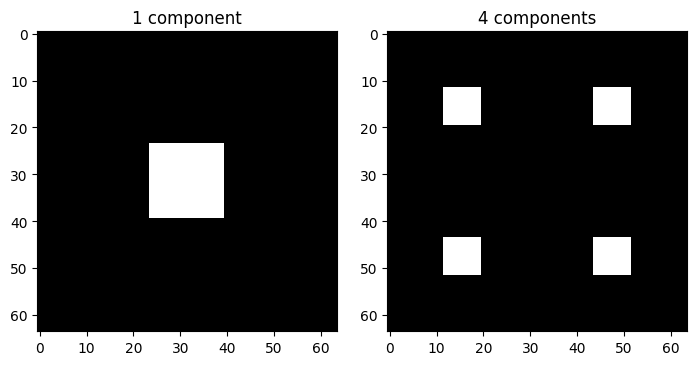

In [2]:
def make_equal_area_patterns():
    single = np.zeros((64, 64))
    multiple = np.zeros_like(single)
    single[24:40, 24:40] = 1
    for y in [12, 44]:
        for x in [12, 44]:
            multiple[y:y+8, x:x+8] = 1
    return single, multiple


single, multiple = make_equal_area_patterns()
assert single.sum() == multiple.sum() == 256
assert component_count(single) == 1 and component_count(multiple) == 4
display(pd.DataFrame([dict(image=name, area=area_fraction(field), components=component_count(field))
                      for name, field in [('single', single), ('multiple', multiple)]]))
fig, axes = plt.subplots(1, 2, figsize=(7, 3.5), constrained_layout=True)
for ax, field, name in zip(axes, [single, multiple], ['1 component', '4 components']):
    ax.imshow(field, cmap='gray', vmin=0, vmax=1)
    ax.set_title(name)
plt.show()

## 解答例：近傍と境界の規約

In [3]:
def make_diagonal_touch_example():
    image = np.zeros((5, 5))
    image[1, 1] = image[2, 2] = 1
    return image


diagonal = make_diagonal_touch_example()
assert component_count(diagonal, connectivity=4) == 2
assert component_count(diagonal, connectivity=8) == 1
edge = np.zeros((8, 8))
edge[2:6, 0] = edge[2:6, -1] = 1
rows = []
for name, field in [('diagonal', diagonal), ('opposite edges', edge)]:
    for connectivity in [4, 8]:
        for periodic in [False, True]:
            rows.append(dict(image=name, connectivity=connectivity, periodic=periodic,
                             components=component_count(field, connectivity=connectivity, periodic=periodic)))
display(pd.DataFrame(rows))
assert component_count(edge) == 2 and component_count(edge, periodic=True) == 1

,image,connectivity,periodic,components
0,diagonal,4,False,2
1,diagonal,4,True,2
2,diagonal,8,False,1
3,diagonal,8,True,1
4,opposite edges,4,False,2
5,opposite edges,4,True,1
6,opposite edges,8,False,2
7,opposite edges,8,True,1


## 解答例：ノイズ・閾値・平滑化への感度

ノイズの基礎乱数を共通にして強度の効果を比べる．別seedでも繰り返し，閾値と平滑化幅も記録する．ここでは周期人工画像なので平滑化と連結の両方を周期境界で扱う．写真にそのまま適用する前に境界の規約を見直す．

In [4]:
def noise_sensitivity(image, noise_levels, seed, threshold=0.5, smooth_sigma=0):
    image = image_array(image)
    if smooth_sigma < 0:
        raise ValueError('smooth_sigma must be nonnegative')
    base_noise = np.random.default_rng(seed).standard_normal(image.shape)
    rows = []
    for sigma in noise_levels:
        if not np.isfinite(sigma) or sigma < 0:
            raise ValueError('noise levels must be finite and nonnegative')
        # 切り詰めは行わない．人工縞が周期的なので平滑化の境界も wrap とする．
        noisy = image + sigma*base_noise
        processed = ndimage.gaussian_filter(noisy, smooth_sigma, mode='wrap') if smooth_sigma else noisy
        rows.append(dict(seed=seed, noise_sigma=sigma, threshold=threshold, smooth_sigma=smooth_sigma,
                         area=area_fraction(processed, threshold),
                         components=component_count(processed, threshold, periodic=True),
                         wavelength=dominant_wavelength(processed)))
    return pd.DataFrame(rows)


stripes = make_stripes()
tables = [noise_sensitivity(stripes, [0, 0.1, 0.3], seed, threshold, smoothing)
          for seed in [0, 1] for threshold in [0.3, 0.5, 0.7] for smoothing in [0, 1]]
noise_table = pd.concat(tables, ignore_index=True)
display(noise_table)
display(noise_table.groupby(['noise_sigma', 'threshold', 'smooth_sigma'])[
    ['area', 'components', 'wavelength']].agg(['mean', 'min', 'max']))

,seed,noise_sigma,threshold,smooth_sigma,area,components,wavelength
0,0,0.0,0.3,0,0.656250,6,32.0
1,0,0.1,0.3,0,0.634494,162,32.0
2,0,0.3,0.3,0,0.650201,561,32.0
3,0,0.0,0.3,1,0.656250,6,32.0
4,0,0.1,0.3,1,0.635525,6,32.0
5,0,0.3,0.3,1,0.638862,18,32.0
6,0,0.0,0.5,0,0.484375,6,32.0
7,0,0.1,0.5,0,0.499539,85,32.0
8,0,0.3,0.5,0,0.499159,787,32.0
9,0,0.0,0.5,1,0.494792,6,32.0


area                     components  \
                                        mean       min       max       mean   
noise_sigma threshold smooth_sigma                                            
0.0         0.3       0             0.656250  0.656250  0.656250        6.0   
                      1             0.656250  0.656250  0.656250        6.0   
            0.5       0             0.484375  0.484375  0.484375        6.0   
                      1             0.494792  0.494792  0.494792        6.0   
            0.7       0             0.343750  0.343750  0.343750        6.0   
                      1             0.343750  0.343750  0.343750        6.0   
0.1         0.3       0             0.634318  0.634142  0.634494      159.0   
                      1             0.636013  0.635525  0.636502        6.0   
            0.5       0             0.499512  0.499485  0.499539       88.0   
                      1             0.499959  0.499729  0.500190        6.0   
            0.7       0             0.364488  0.363824  0.365153       75.0   
                      1             0.363295  0.362549  0.364041        6.0   
0.3         0.3       0             0.649048  0.647895  0.650201      559.5   
                      1             0.637722  0.636583  0.638862       13.5   
            0.5       0             0.499254  0.499159  0.499349      764.0   
                      1             0.499010  0.498372  0.499647        9.0   
            0.7       0             0.348741  0.347738  0.349745      657.5   
                      1             0.362481  0.362061  0.362901       12.0   

                                             wavelength              
                                    min  max       mean   min   max  
noise_sigma threshold smooth_sigma                                   
0.0         0.3       0               6    6       32.0  32.0  32.0  
                      1               6    6       32.0  32.0  32.0  
            0.5       0               6    6       32.0  32.0  32.0  
                      1               6    6       32.0  32.0  32.0  
            0.7       0               6    6       32.0  32.0  32.0  
                      1               6    6       32.0  32.0  32.0  
0.1         0.3       0             156  162       32.0  32.0  32.0  
                      1               6    6       32.0  32.0  32.0  
            0.5       0              85   91       32.0  32.0  32.0  
                      1               6    6       32.0  32.0  32.0  
            0.7       0              68   82       32.0  32.0  32.0  
                      1               6    6       32.0  32.0  32.0  
0.3         0.3       0             558  561       32.0  32.0  32.0  
                      1               9   18       32.0  32.0  32.0  
            0.5       0             741  787       32.0  32.0  32.0  
                      1               7   11       32.0  32.0  32.0  
            0.7       0             620  695       32.0  32.0  32.0  
                      1               9   15       32.0  32.0  32.0

## 解答例：既知波長・一定画像・長方形画像

In [5]:
def wavelength_checks():
    rows = []
    constant = np.ones((32, 48))
    assert np.isnan(dominant_wavelength(constant))
    rows.append(dict(case='constant', expected=np.nan, measured=dominant_wavelength(constant)))
    for wavelength in [16, 32, 192]:
        field = make_stripes(wavelength=wavelength)
        measured = dominant_wavelength(field)
        np.testing.assert_allclose(measured, wavelength)
        rows.append(dict(case=f'square, period {wavelength}', expected=wavelength, measured=measured))
    rectangular = make_stripes(size=192, wavelength=32)[:96, :]
    measured = dominant_wavelength(rectangular, pixel_size=(2.0, 0.5))
    np.testing.assert_allclose(measured, 16)
    rows.append(dict(case='rectangle, dx=0.5', expected=16, measured=measured))
    np.testing.assert_allclose(make_stripes(wavelength=16).var(), make_stripes(wavelength=32).var())
    shifted = np.roll(rectangular, (3, 5), axis=(0, 1))
    np.testing.assert_allclose(spectrum_data(rectangular)[2], spectrum_data(shifted)[2], atol=1e-14)
    return pd.DataFrame(rows)


display(wavelength_checks())

,case,expected,measured
0,constant,NaN,NaN
1,"square, period 16",16.0,16.0
2,"square, period 32",32.0,32.0
3,"square, period 192",192.0,192.0
4,"rectangle, dx=0.5",16.0,16.0


## 解答例：特徴量の意味と限界

前景256画素の2例は面積比が0.0625で同じでも成分数は1と4になる．斜めの接触は近傍規約，両端への分割は境界規約に依存する．波長16と32の余弦波は異なる間隔だが分散は同じなので，分散だけでは細かさを比較できない．

ノイズによる小さな前景や連結の切断は成分数へ影響する．平滑化でそれを減らしても，細い模様も同時に消す可能性がある．今回の規則的な縞では波長のピークが安定でも，周期性が弱い実画像に一般化はできない．各特徴量の変動と画像・スペクトルを併せて示す．